# Dense Shelf Water transformation budget

We compute the water mass transformation budget for the Antarctic continental shelf (south of 50°S and shallower than 1000 m) in σ2 classes, integrated over the shelf, for the piControl and Historical/SSP5-8.5 experiments (1850–2099). We also decompose the surface flux term into its individual heat and salt fluxes. The monthly result is used by `03_prepare_dsw_densities_and_periods` and the figure notebooks.

In [1]:
import sys
import warnings

import xarray as xr
import xbudget
import xwmb
import CM4Xutils

sys.path.insert(0, "../src")
from paths import outputdir
from cm4x import cm4x_budget_files, open_cm4x_budget, cm4x_acs_region

output = outputdir("Southern_Ocean_DSW_1000m_WMT_Budget.zarr")
budget_yaml = "MOM6_AABW_updated.yaml"  # xbudget definition of the mass budget terms

In [2]:
from dask.distributed import Client
from dask_jobqueue import SLURMCluster

# 8 nodes (36 cores, 160 GB each) for the xwmb budgets over 50 five-year files
cluster = SLURMCluster(cores=36, processes=4, memory="160GB", walltime="06:00:00",
                       queue="scavenger", log_directory="logs")
cluster.scale(jobs=8)
cluster.wait_for_workers(2)
client = Client(cluster)
client

<Client: 'tcp://10.151.1.98:34141' processes=8 threads=72, memory=298.00 GiB>

## Budget terms

In [3]:
budget_terms = [
    "Eulerian_tendency", "advection", "diffusion", "diffusion_heat", "diffusion_salt",
    "boundary_fluxes", "convergent_mass_transport", "mass_tendency", "mass_source",
    "spurious_numerical_mixing", "surface_exchange_flux", "bottom_flux", "frazil_ice",
    "surface_ocean_flux_advective_negative_rhs",
    "surface_ocean_flux_advective_negative_rhs_heat", "surface_ocean_flux_advective_negative_rhs_salt",
    "surface_exchange_flux_heat", "surface_exchange_flux_salt", "frazil_ice_heat", "bottom_flux_heat",
]

# individual surface fluxes from decomposing surface_exchange_flux
decomp_budget_terms = [
    "surface_exchange_flux_advective_evaporation_salt",
    "surface_exchange_flux_advective_rain_and_ice_salt",
    "surface_exchange_flux_advective_snow_salt",
    "surface_exchange_flux_advective_rivers_salt",
    "surface_exchange_flux_advective_icebergs_salt",
    "surface_exchange_flux_advective_virtual_precip_restoring_salt",
    "surface_exchange_flux_advective_sea_ice_salt",
    "surface_exchange_flux_nonadvective_basal_salt",
    "surface_exchange_flux_nonadvective_longwave_heat",
    "surface_exchange_flux_nonadvective_shortwave_heat",
    "surface_exchange_flux_nonadvective_sensible_heat",
    "surface_exchange_flux_nonadvective_latent_heat",
    "surface_exchange_flux_advective_mass_transfer_heat",
]


def split_boundary_fluxes(wmt):
    """Heat and salt contributions to the boundary fluxes."""
    wmt["boundary_fluxes_heat"] = (
        wmt["surface_ocean_flux_advective_negative_rhs_heat"] + wmt["surface_exchange_flux_heat"]
        + wmt["frazil_ice_heat"] + wmt["bottom_flux_heat"]
    )
    wmt["boundary_fluxes_salt"] = wmt["surface_ocean_flux_advective_negative_rhs_salt"] + wmt["surface_exchange_flux_salt"]
    wmt["surface_boundary_fluxes_salt"] = 1 * wmt["boundary_fluxes_salt"]
    wmt["surface_boundary_fluxes_heat"] = wmt["boundary_fluxes_heat"] - wmt["bottom_flux_heat"]
    return wmt


def lazy_budget(files):
    """Integrated budget and surface-flux decomposition for consecutive 5-year files, as one lazy dataset."""
    ds = open_cm4x_budget(files).fillna(0.0)
    grid = CM4Xutils.ds_to_grid(ds)
    region = cm4x_acs_region(ds, grid)

    with warnings.catch_warnings():
        warnings.simplefilter(action="ignore", category=FutureWarning)
        budgets_dict = xbudget.load_yaml(budget_yaml)
        xbudget.collect_budgets(grid, budgets_dict)

        # full budget of water denser than each sigma2 class; the shelf is passed as a mask here
        wmb = xwmb.WaterMassBudget(grid, budgets_dict, region=region.mask)
        wmb.mass_budget("sigma2", greater_than=True, bins=None, integrate=True, along_section=False)
        wmt = split_boundary_fluxes(wmb.wmt[budget_terms])

        # surface flux components (evaporation, sea ice, sensible heat, ...)
        wmb_decomp = xwmb.WaterMassBudget(
            grid, budgets_dict, region=region,
            decompose=["surface_exchange_flux", "nonadvective", "advective"],
        )
        wmb_decomp.mass_budget("sigma2", greater_than=True, bins=None, integrate=True, along_section=False)
        wmt_decomp = wmb_decomp.wmt[decomp_budget_terms]

    return xr.merge([wmt_decomp, wmt])

## Budget, computed in batches of files

Each batch of 5-year files is opened as one dataset; the budget is built on it once and computed into memory.

In [ ]:
batch_size = 10  # Number of 5-year files computed together in one dask graph; set to len(files) to compute everything at once
files = cm4x_budget_files(first_year=1850)
batches = [files[i:i + batch_size] for i in range(0, len(files), batch_size)]

wmts = []
for batch in batches:
    print(batch[0].split("/")[-1], "...", batch[-1].split("/")[-1])
    result = lazy_budget(batch).compute()
    assert not (result["boundary_fluxes"] == 0).all("sigma2_l_target").any(), "all-zero months: check how the files were combined"
    wmts.append(result)

wmts = xr.concat(wmts, dim="time")

CM4Xp125_budgets_sigma2_1850-1854.zarr ... CM4Xp125_budgets_sigma2_1895-1899.zarr
Inferring Z grid coordinate: density `sigma2`


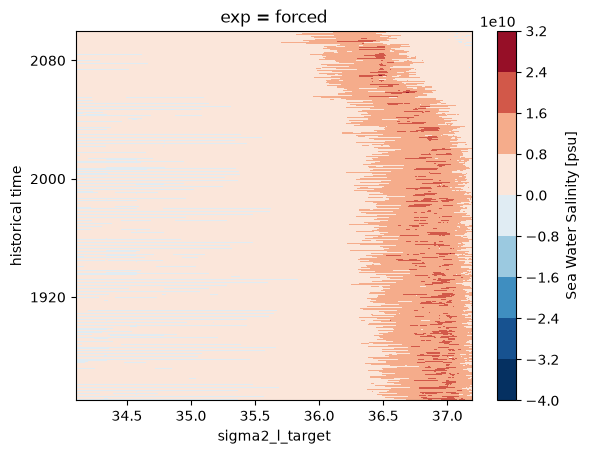

In [8]:
wmts["boundary_fluxes"].sel(exp = "forced").sel(sigma2_l_target = slice(34, 37.2)).plot.contourf()

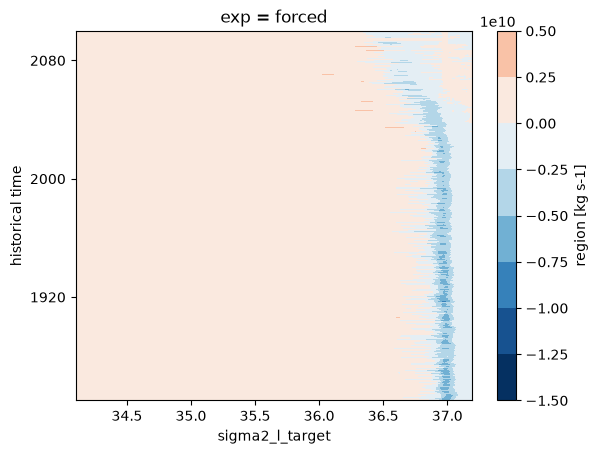

In [9]:
wmts["convergent_mass_transport"].sel(exp = "forced").sel(sigma2_l_target = slice(34, 37.2)).plot.contourf()

## Check and save

The heat and salt boundary fluxes should add up to the total boundary flux.

In [11]:
residual = wmts["boundary_fluxes"] - (wmts["boundary_fluxes_heat"] + wmts["boundary_fluxes_salt"])
print("max |residual| / max |boundary_fluxes|:", float(abs(residual).max() / abs(wmts["boundary_fluxes"]).max()))

wmts.to_zarr(output, mode="w")

max |residual| / max |boundary_fluxes|: 2.3777102204536204e-16


/user/anthony.meza/miniforge3/envs/cm4x_chapter2/lib/python3.11/site-packages/zarr/api/asynchronous.py:247: ZarrUserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(
